In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import random
import numpy as np
import copy
import matplotlib.pyplot as plt


import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

/gpu-data2/kfot/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fcs = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input for the fully connected layer
        x = self.fc1(x)
        x = self.relu(x)
        for layer in self.fcs:
            x = layer(x)
            x = self.relu(x)
        x = self.fc2(x)
        return x

class MaxoutLayer(nn.Module):
    def __init__(self, input_size, output_size, pool_size=2, aggregate='max'):
        super(MaxoutLayer, self).__init__()
        self.output_size = output_size
        self.pool_size = pool_size
        # Create two linear transformations for the maxout operation
        self.linear = nn.ModuleList([nn.Linear(input_size, output_size) for _ in range(pool_size)])

    def forward(self, x):
        # Apply each linear layer and stack the results
        maxout_layers = torch.stack([layer(x) for layer in self.linear], dim=2)  # Shape: (batch, output_size, pool_size)
        # Take the max across the pool_size dimension
        maxout_output = torch.max(maxout_layers, dim=2).values  # Shape: (batch, output_size)
        return maxout_output

class Maxout(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Maxout, self).__init__()
        self.maxout1 = MaxoutLayer(input_size, hidden_size, pool_size=2)
        self.maxouts = nn.ModuleList([MaxoutLayer(hidden_size, hidden_size) for _ in range(n_layers)])
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.maxout1(x)
        for layer in self.maxouts:
            x = layer(x)
        x = self.output(x)
        return x

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, method='max', l=None, alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.method = method
        self.bias = bias

        self.w = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        if bias:
            self.b = nn.Parameter(torch.randn(output_size))
            if method == 'max-plus-min' or method == 'dep':
                self.b2 = nn.Parameter(torch.randn(output_size))
        if method == 'dep':
            self.w2 = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
            if l == None:
                self.l = nn.Parameter(torch.rand(output_size))
            else:
                self.l = l + torch.zeros(output_size).to(device)

    def forward(self, x, dropout=None):
        x = x.unsqueeze(1) 
        if dropout:
            mask = torch.rand(self.w.size(0), self.w.size(1)) < dropout
            mask = mask.to(device)
        if self.method == 'max':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.method == 'min':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.min(x, dim=2)
        elif self.method == 'max-plus-min':
            max_w = self.w
            min_w = self.w
            if dropout:
                max_w = max_w - mask * 1e9
                min_w = min_w + mask * 1e9
            x_max = x + max_w
            x_min = x + min_w
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            x = x_max + x_min
        elif self.method == 'dep':
            x_max = x + self.w
            x_min = x + self.w2
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x_max.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x_min.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            l = self.l.view(1,-1)
            l = torch.clamp(l, 0, 1)
            x = l * x_max + (1-l) * x_min
        return x
    
class LinAct(nn.Module):
    def __init__(self, size, method="simple"):
        super(LinAct, self).__init__()
        self.size = size
        self.method = method
        if method == "simple":
            self.a = nn.Parameter(torch.randn(size) / 3.46)
            # self.a = nn.Parameter(torch.rand(size)-0.5)
        else:
            tmp = nn.Linear(size, size, bias = False).weight.detach()
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.V = torch.tensor(Vh).t().to(device)
            self.a = torch.zeros(size).to(device)
            self.a[:S.shape[0]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)

    def forward(self, x):
        if self.method == "simple":
            x = x * self.a.view(1, -1).repeat(x.size(0), 1)
        else:
            Smat = torch.diag(self.a)
            tmp = self.U @ Smat @ self.V.t()
            x = torch.mm(x, tmp.t())
        return x
    
# class Repeater(nn.Module):
#     def __init__(self, r):
#         super(Repeater, self).__init__()
#         self.r = r
#     def forward(self, x):
#         x = x.repeat(1, self.r)
#         return x
    
class MPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class RMPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(RMPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = x + layer(x)
        x = self.morph_layer2(x)
        return x
    
class RMPM_Drop(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, dropout=0.5):
        super(RMPM_Drop, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

        self.dropout = dropout

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        if self.training:
            x = self.morph_layer1(x, self.dropout)
        else:
            x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            if self.training:
                x = x + layer[1](layer[0](x, self.dropout))
            else:
                x = x + layer(x)
        if self.training:
            x = self.morph_layer2(x, self.dropout)
        else:
            x = self.morph_layer2(x)
        return x
    
class MPM_SVD(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM_SVD, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size, method='svd')
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size, method='svd')) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class HybridMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(HybridMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.morph_layer1 = MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min')
        self.layers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_size, hidden_size), 
                           MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min'))
             for _ in range(n_layers)]
            )
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.fc1(x)
        x = self.morph_layer1(x)
        for layer in self.layers:
            x = layer(x)
        x = self.fc2(x)
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Act_MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias=False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(Act_DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias = False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class MinMaxPlus(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MinMaxPlus, self).__init__()
        self.multipliers = LinAct(input_size, method="simple")
        self.morph_layer1 = nn.Sequential(
            MorphologicalLayer(input_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
        )
        self.morph_layers = nn.ModuleList([
            nn.Sequential(
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='max'), 
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
            ) 
            for _ in range(n_layers)
            ]
        )
        self.morph_layer2 = nn.Sequential(
            MorphologicalLayer(hidden_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, num_classes, bias=False, method='min')
        )

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.multipliers(x)
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class Negator(nn.Module):
    def __init__(self):
        super(Negator, self).__init__()
    def forward(self, x):
        x = torch.cat([x, -x], dim=-1)
        return x

class MinMaxPlus_neg(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MinMaxPlus_neg, self).__init__()
        self.multipliers = LinAct(input_size, method="simple")
        self.morph_layer1 = nn.Sequential( 
            Negator(), 
            MorphologicalLayer(2*input_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
        )
        self.morph_layers = nn.ModuleList([
            nn.Sequential(
                Negator(), 
                MorphologicalLayer(2*hidden_size, hidden_size, bias=False, method='max'), 
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
            ) 
            for _ in range(n_layers)
            ]
        )
        self.morph_layer2 = nn.Sequential(
            Negator(), 
            MorphologicalLayer(2*hidden_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, num_classes, bias=False, method='min')
        )

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.multipliers(x)
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

    
class MorphConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=True, method="max-plus-min", alpha=1.0):
        super(MorphConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias
        self.method = method
        self.alpha = alpha

        self.weight = nn.Parameter(
            torch.normal(mean=0.0, std=alpha, size=(out_channels, in_channels, kernel_size[0], kernel_size[1]))
        )
        if bias:
            self.b = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))
            self.b2 = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))

    def forward(self, x):
        # Max morphological operation
        x_max = torch.exp(x)
        w_max = torch.exp(self.weight)
        if self.bias:
            b_max = torch.exp(self.b)
            x_max = F.conv2d(x_max, w_max, b_max, stride=self.stride, padding=self.padding)
        else:
            x_max = F.conv2d(x_max, w_max, stride=self.stride, padding=self.padding)
        x_max = torch.log(x_max)

        # Min morphological operation
        x_min = torch.exp(-x)
        w_min = torch.exp(-self.weight)
        if self.bias:
            b_min = torch.exp(-self.b2)
            x_min = F.conv2d(x_min, w_min, b_min, stride=self.stride, padding=self.padding)
        else:
            x_min = F.conv2d(x_min, w_min, stride=self.stride, padding=self.padding)
        x_min = -torch.log(x_min)

        # Aggregation of max and min operations
        if self.method == "max":
            x_out = x_max
        elif self.method == "min":
            x_out = x_min
        else:
            x_out = x_max + x_min

        return x_out
    
class ConvLinAct(nn.Module):
    def __init__(self, channels, method="simple"):
        super(ConvLinAct, self).__init__()
        self.method = method

        if method == 'simple':
            # self.a = nn.Parameter(torch.randn(channels, size, size)/3.46)
            # self.a = nn.Parameter(torch.rand(channels)-0.5)
            self.a = nn.Parameter(torch.randn(3, 3, channels))
        else:
            tmp = nn.Conv2d(channels, channels, 3, bias = False).weight.data.detach()
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.Vh = torch.tensor(Vh).to(device)
            self.a = torch.zeros(3, 3, channels).to(device)
            self.a[:, :, :S.shape[2]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)
    def forward(self, x):
        if self.method == 'simple':
            # x = x * self.a.unsqueeze(-1).unsqueeze(-1).unsqueeze(0).repeat(x.size(0), 1, x.size(2), x.size(3))
            tmp = torch.diag_embed(self.a)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        else:
            tmp = self.U @ (self.a.unsqueeze(-1) * self.Vh)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        return x
    
class MPM_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="simple")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="simple")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="simple")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84)
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class MPM_SVD_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_SVD_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="svd")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="svd")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="svd")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84, method="svd")
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(LeNet5, self).__init__()
                  
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding = 1)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding = 1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, padding = 1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.layer1 = nn.Linear(120, 84)
        self.layer2 = nn.Linear(84, n_classes, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x
    

In [4]:
def train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50, return_list=False):
    # Training and validation loop
    best_val_accuracy = 0.0
    best_model = None

    train_list = []
    val_list = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_list.append(train_accuracy)
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_list.append(val_accuracy)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

        # Save best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = copy.deepcopy(model)

    if return_list:
        return best_model, train_list, val_list
    else:
        return best_model

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy on the test set: {accuracy:.2f}%')

In [5]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='../data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='../data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [11]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.1782, Train Accuracy: 94.10%, Validation Accuracy: 94.00%
Epoch [2/50], Loss: 0.3915, Train Accuracy: 95.59%, Validation Accuracy: 94.76%
Epoch [3/50], Loss: 0.1087, Train Accuracy: 96.84%, Validation Accuracy: 95.89%
Epoch [4/50], Loss: 0.1588, Train Accuracy: 96.35%, Validation Accuracy: 95.63%
Epoch [5/50], Loss: 0.1096, Train Accuracy: 96.26%, Validation Accuracy: 95.16%
Epoch [6/50], Loss: 0.1066, Train Accuracy: 97.85%, Validation Accuracy: 96.71%
Epoch [7/50], Loss: 0.0420, Train Accuracy: 97.72%, Validation Accuracy: 96.74%
Epoch [8/50], Loss: 0.0321, Train Accuracy: 98.19%, Validation Accuracy: 97.16%
Epoch [9/50], Loss: 0.1082, Train Accuracy: 98.39%, Validation Accuracy: 97.18%
Epoch [10/50], Loss: 0.0121, Train Accuracy: 98.62%, Validation Accuracy: 97.22%
Epoch [11/50], Loss: 0.1173, Train Accuracy: 98.08%, Validation Accuracy: 96.71%
Epoch [12/50], Loss: 0.0990, Train Accuracy: 98.71%, Validation Accuracy: 96.97%
Ep

In [12]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.95%


In [13]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.3086, Train Accuracy: 13.53%, Validation Accuracy: 13.74%


Epoch [2/50], Loss: 2.2335, Train Accuracy: 19.48%, Validation Accuracy: 20.23%
Epoch [3/50], Loss: 2.2651, Train Accuracy: 19.92%, Validation Accuracy: 20.22%
Epoch [4/50], Loss: 2.1184, Train Accuracy: 21.16%, Validation Accuracy: 22.03%
Epoch [5/50], Loss: 2.2105, Train Accuracy: 21.51%, Validation Accuracy: 22.23%
Epoch [6/50], Loss: 2.2033, Train Accuracy: 22.49%, Validation Accuracy: 23.35%
Epoch [7/50], Loss: 2.2319, Train Accuracy: 23.94%, Validation Accuracy: 24.78%
Epoch [8/50], Loss: 2.1306, Train Accuracy: 25.35%, Validation Accuracy: 26.24%
Epoch [9/50], Loss: 2.1624, Train Accuracy: 27.70%, Validation Accuracy: 28.25%
Epoch [10/50], Loss: 2.2164, Train Accuracy: 27.64%, Validation Accuracy: 28.37%
Epoch [11/50], Loss: 2.1488, Train Accuracy: 28.06%, Validation Accuracy: 28.70%
Epoch [12/50], Loss: 2.0833, Train Accuracy: 28.12%, Validation Accuracy: 28.69%
Epoch [13/50], Loss: 2.1298, Train Accuracy: 28.10%, Validation Accuracy: 28.77%
Epoch [14/50], Loss: 2.0681, Train A

In [14]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 29.90%


In [15]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106
Epoch [1/50], Loss: 2.2014, Train Accuracy: 33.40%, Validation Accuracy: 33.33%
Epoch [2/50], Loss: 2.0535, Train Accuracy: 43.25%, Validation Accuracy: 43.40%


Epoch [3/50], Loss: 1.9471, Train Accuracy: 47.91%, Validation Accuracy: 48.15%
Epoch [4/50], Loss: 1.8162, Train Accuracy: 52.58%, Validation Accuracy: 52.62%
Epoch [5/50], Loss: 1.7207, Train Accuracy: 57.31%, Validation Accuracy: 57.43%
Epoch [6/50], Loss: 1.7484, Train Accuracy: 55.99%, Validation Accuracy: 56.83%
Epoch [7/50], Loss: 1.6934, Train Accuracy: 58.03%, Validation Accuracy: 58.19%
Epoch [8/50], Loss: 1.6910, Train Accuracy: 62.78%, Validation Accuracy: 63.21%
Epoch [9/50], Loss: 1.7021, Train Accuracy: 64.17%, Validation Accuracy: 64.55%
Epoch [10/50], Loss: 1.6550, Train Accuracy: 64.74%, Validation Accuracy: 65.05%
Epoch [11/50], Loss: 1.6869, Train Accuracy: 66.23%, Validation Accuracy: 66.27%
Epoch [12/50], Loss: 1.6134, Train Accuracy: 67.97%, Validation Accuracy: 67.78%
Epoch [13/50], Loss: 1.6188, Train Accuracy: 67.45%, Validation Accuracy: 67.17%
Epoch [14/50], Loss: 1.5773, Train Accuracy: 68.98%, Validation Accuracy: 68.74%
Epoch [15/50], Loss: 1.6706, Train 

In [16]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 78.43%


In [7]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.2107, Train Accuracy: 45.67%, Validation Accuracy: 45.43%
Epoch [2/50], Loss: 2.0921, Train Accuracy: 53.19%, Validation Accuracy: 52.58%
Epoch [3/50], Loss: 1.9889, Train Accuracy: 58.65%, Validation Accuracy: 58.23%
Epoch [4/50], Loss: 1.9732, Train Accuracy: 63.47%, Validation Accuracy: 63.12%
Epoch [5/50], Loss: 1.9048, Train Accuracy: 66.74%, Validation Accuracy: 66.26%
Epoch [6/50], Loss: 1.8856, Train Accuracy: 71.06%, Validation Accuracy: 70.58%
Epoch [7/50], Loss: 1.8895, Train Accuracy: 66.85%, Validation Accuracy: 66.52%
Epoch [8/50], Loss: 1.9253, Train Accuracy: 70.11%, Validation Accuracy: 69.92%
Epoch [9/50], Loss: 1.9177, Train Accuracy: 71.00%, Validation Accuracy: 70.60%
Epoch [10/50], Loss: 1.8909, Train Accuracy: 70.39%, Validation Accuracy: 69.91%
Epoch [11/50], Loss: 1.8882, Train Accuracy: 69.83%, Validation Accuracy: 69.64%
Epoch [12/50], Loss: 1.8107, Train Accuracy: 69.06%, Validation Accuracy: 68.62%
Ep

In [8]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 76.93%


In [17]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978
Epoch [1/50], Loss: 2.2909, Train Accuracy: 9.67%, Validation Accuracy: 10.01%
Epoch [2/50], Loss: 1.9587, Train Accuracy: 21.98%, Validation Accuracy: 22.41%


Epoch [3/50], Loss: 2.0224, Train Accuracy: 24.17%, Validation Accuracy: 24.56%
Epoch [4/50], Loss: 1.8142, Train Accuracy: 26.94%, Validation Accuracy: 27.65%
Epoch [5/50], Loss: 1.7549, Train Accuracy: 32.64%, Validation Accuracy: 32.37%
Epoch [6/50], Loss: 1.7350, Train Accuracy: 36.08%, Validation Accuracy: 35.72%
Epoch [7/50], Loss: 1.6397, Train Accuracy: 37.33%, Validation Accuracy: 37.21%
Epoch [8/50], Loss: 1.7726, Train Accuracy: 39.87%, Validation Accuracy: 39.32%
Epoch [9/50], Loss: 1.6749, Train Accuracy: 38.01%, Validation Accuracy: 37.72%
Epoch [10/50], Loss: 1.5079, Train Accuracy: 38.30%, Validation Accuracy: 38.31%
Epoch [11/50], Loss: 1.6705, Train Accuracy: 38.40%, Validation Accuracy: 38.35%
Epoch [12/50], Loss: 1.6614, Train Accuracy: 40.58%, Validation Accuracy: 40.23%
Epoch [13/50], Loss: 1.7018, Train Accuracy: 38.91%, Validation Accuracy: 39.29%
Epoch [14/50], Loss: 1.5449, Train Accuracy: 38.59%, Validation Accuracy: 38.51%
Epoch [15/50], Loss: 1.6098, Train 

In [18]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 46.04%


In [19]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386
Epoch [1/50], Loss: 2.2885, Train Accuracy: 11.25%, Validation Accuracy: 11.17%
Epoch [2/50], Loss: 2.0010, Train Accuracy: 35.10%, Validation Accuracy: 35.67%


Epoch [3/50], Loss: 1.7698, Train Accuracy: 43.93%, Validation Accuracy: 44.41%
Epoch [4/50], Loss: 1.5567, Train Accuracy: 51.74%, Validation Accuracy: 52.19%
Epoch [5/50], Loss: 1.2493, Train Accuracy: 59.59%, Validation Accuracy: 59.88%
Epoch [6/50], Loss: 1.3185, Train Accuracy: 63.75%, Validation Accuracy: 64.55%
Epoch [7/50], Loss: 1.2393, Train Accuracy: 67.39%, Validation Accuracy: 67.73%
Epoch [8/50], Loss: 1.0302, Train Accuracy: 69.90%, Validation Accuracy: 70.12%
Epoch [9/50], Loss: 1.0115, Train Accuracy: 71.64%, Validation Accuracy: 71.77%
Epoch [10/50], Loss: 0.9687, Train Accuracy: 74.09%, Validation Accuracy: 73.97%
Epoch [11/50], Loss: 0.9713, Train Accuracy: 75.34%, Validation Accuracy: 75.15%
Epoch [12/50], Loss: 0.8041, Train Accuracy: 76.43%, Validation Accuracy: 76.13%
Epoch [13/50], Loss: 0.7187, Train Accuracy: 77.61%, Validation Accuracy: 77.63%
Epoch [14/50], Loss: 0.6245, Train Accuracy: 78.57%, Validation Accuracy: 78.30%
Epoch [15/50], Loss: 0.8463, Train 

In [20]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 85.61%


In [21]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.2901, Train Accuracy: 11.25%, Validation Accuracy: 11.17%


Epoch [2/50], Loss: 2.0891, Train Accuracy: 47.66%, Validation Accuracy: 47.17%
Epoch [3/50], Loss: 1.1783, Train Accuracy: 76.10%, Validation Accuracy: 75.66%
Epoch [4/50], Loss: 0.8307, Train Accuracy: 80.35%, Validation Accuracy: 79.66%
Epoch [5/50], Loss: 0.5889, Train Accuracy: 82.83%, Validation Accuracy: 82.40%
Epoch [6/50], Loss: 0.7080, Train Accuracy: 85.01%, Validation Accuracy: 84.64%
Epoch [7/50], Loss: 0.6844, Train Accuracy: 86.33%, Validation Accuracy: 85.79%
Epoch [8/50], Loss: 0.4644, Train Accuracy: 87.36%, Validation Accuracy: 87.16%
Epoch [9/50], Loss: 0.5013, Train Accuracy: 88.29%, Validation Accuracy: 87.94%
Epoch [10/50], Loss: 0.6015, Train Accuracy: 88.94%, Validation Accuracy: 88.67%
Epoch [11/50], Loss: 0.3796, Train Accuracy: 89.53%, Validation Accuracy: 89.09%
Epoch [12/50], Loss: 0.4745, Train Accuracy: 89.92%, Validation Accuracy: 89.55%
Epoch [13/50], Loss: 0.3558, Train Accuracy: 90.40%, Validation Accuracy: 89.97%
Epoch [14/50], Loss: 0.3311, Train A

In [22]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 93.10%


In [23]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.1213, Train Accuracy: 63.60%, Validation Accuracy: 62.78%


Epoch [2/50], Loss: 0.9756, Train Accuracy: 83.98%, Validation Accuracy: 83.71%
Epoch [3/50], Loss: 0.5726, Train Accuracy: 87.94%, Validation Accuracy: 87.65%
Epoch [4/50], Loss: 0.3435, Train Accuracy: 90.07%, Validation Accuracy: 89.65%
Epoch [5/50], Loss: 0.2194, Train Accuracy: 91.43%, Validation Accuracy: 90.55%
Epoch [6/50], Loss: 0.4229, Train Accuracy: 92.29%, Validation Accuracy: 91.41%
Epoch [7/50], Loss: 0.2881, Train Accuracy: 93.11%, Validation Accuracy: 92.08%
Epoch [8/50], Loss: 0.3153, Train Accuracy: 93.65%, Validation Accuracy: 92.53%
Epoch [9/50], Loss: 0.2282, Train Accuracy: 94.14%, Validation Accuracy: 92.81%
Epoch [10/50], Loss: 0.1428, Train Accuracy: 94.50%, Validation Accuracy: 92.97%
Epoch [11/50], Loss: 0.0761, Train Accuracy: 94.92%, Validation Accuracy: 93.41%
Epoch [12/50], Loss: 0.1098, Train Accuracy: 95.19%, Validation Accuracy: 93.58%
Epoch [13/50], Loss: 0.1764, Train Accuracy: 95.52%, Validation Accuracy: 93.81%
Epoch [14/50], Loss: 0.1485, Train A

In [24]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.42%


In [6]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 859408
Epoch [1/50], Loss: 2.0231, Train Accuracy: 43.09%, Validation Accuracy: 43.15%
Epoch [2/50], Loss: 1.9154, Train Accuracy: 50.98%, Validation Accuracy: 51.33%
Epoch [3/50], Loss: 1.8312, Train Accuracy: 52.79%, Validation Accuracy: 52.79%
Epoch [4/50], Loss: 1.7893, Train Accuracy: 54.12%, Validation Accuracy: 54.43%
Epoch [5/50], Loss: 1.7290, Train Accuracy: 55.17%, Validation Accuracy: 55.34%
Epoch [6/50], Loss: 1.7339, Train Accuracy: 56.57%, Validation Accuracy: 56.67%
Epoch [7/50], Loss: 1.5256, Train Accuracy: 57.87%, Validation Accuracy: 57.74%
Epoch [8/50], Loss: 1.4534, Train Accuracy: 59.33%, Validation Accuracy: 59.30%
Epoch [9/50], Loss: 1.4249, Train Accuracy: 59.97%, Validation Accuracy: 60.02%
Epoch [10/50], Loss: 1.6055, Train Accuracy: 60.92%, Validation Accuracy: 61.12%
Epoch [11/50], Loss: 1.4213, Train Accuracy: 61.29%, Validation Accuracy: 61.38%
Epoch [12/50], Loss: 1.4192, Train Accuracy: 63.33%, Validation Accuracy: 63.34%
Ep

In [7]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 76.29%


In [6]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus_neg().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 1387792
Epoch [1/50], Loss: 1.9871, Train Accuracy: 47.29%, Validation Accuracy: 47.67%
Epoch [2/50], Loss: 1.9371, Train Accuracy: 50.69%, Validation Accuracy: 51.41%
Epoch [3/50], Loss: 1.8014, Train Accuracy: 53.10%, Validation Accuracy: 53.58%
Epoch [4/50], Loss: 1.7079, Train Accuracy: 55.84%, Validation Accuracy: 56.70%
Epoch [5/50], Loss: 1.6890, Train Accuracy: 57.00%, Validation Accuracy: 57.92%
Epoch [6/50], Loss: 1.5508, Train Accuracy: 58.33%, Validation Accuracy: 59.08%
Epoch [7/50], Loss: 1.5722, Train Accuracy: 59.34%, Validation Accuracy: 60.33%
Epoch [8/50], Loss: 1.4992, Train Accuracy: 60.15%, Validation Accuracy: 61.17%
Epoch [9/50], Loss: 1.4537, Train Accuracy: 60.96%, Validation Accuracy: 61.70%
Epoch [10/50], Loss: 1.3677, Train Accuracy: 64.56%, Validation Accuracy: 65.03%
Epoch [11/50], Loss: 1.3949, Train Accuracy: 65.39%, Validation Accuracy: 66.22%
Epoch [12/50], Loss: 1.3565, Train Accuracy: 66.81%, Validation Accuracy: 67.49%
E

In [7]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 77.04%


In [25]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.6133, Train Accuracy: 85.69%, Validation Accuracy: 85.79%
Epoch [2/50], Loss: 0.4308, Train Accuracy: 90.82%, Validation Accuracy: 90.58%
Epoch [3/50], Loss: 0.3028, Train Accuracy: 92.59%, Validation Accuracy: 91.97%
Epoch [4/50], Loss: 0.1851, Train Accuracy: 93.67%, Validation Accuracy: 92.78%
Epoch [5/50], Loss: 0.1881, Train Accuracy: 94.51%, Validation Accuracy: 93.45%
Epoch [6/50], Loss: 0.2737, Train Accuracy: 95.17%, Validation Accuracy: 93.80%
Epoch [7/50], Loss: 0.3189, Train Accuracy: 95.74%, Validation Accuracy: 93.94%
Epoch [8/50], Loss: 0.1040, Train Accuracy: 96.07%, Validation Accuracy: 94.03%
Epoch [9/50], Loss: 0.2022, Train Accuracy: 96.50%, Validation Accuracy: 94.17%
Epoch [10/50], Loss: 0.0617, Train Accuracy: 96.95%, Validation Accuracy: 94.23%
Epoch [11/50], Loss: 0.1660, Train Accuracy: 97.14%, Validation Accuracy: 94.29%
Epoch [12/50], Loss: 0.1676, Train Accuracy: 97.41%, Validation Accuracy: 94.37%
Epoch [13/50], Loss: 0.0628, Train Ac

In [26]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.47%


In [27]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.4463, Train Accuracy: 88.67%, Validation Accuracy: 88.83%


Epoch [2/50], Loss: 0.2960, Train Accuracy: 92.65%, Validation Accuracy: 92.08%
Epoch [3/50], Loss: 0.1737, Train Accuracy: 94.50%, Validation Accuracy: 93.44%
Epoch [4/50], Loss: 0.2409, Train Accuracy: 95.67%, Validation Accuracy: 93.97%
Epoch [5/50], Loss: 0.2210, Train Accuracy: 96.49%, Validation Accuracy: 94.62%
Epoch [6/50], Loss: 0.1216, Train Accuracy: 97.09%, Validation Accuracy: 94.97%
Epoch [7/50], Loss: 0.1836, Train Accuracy: 97.57%, Validation Accuracy: 95.16%
Epoch [8/50], Loss: 0.0839, Train Accuracy: 97.89%, Validation Accuracy: 95.31%
Epoch [9/50], Loss: 0.1129, Train Accuracy: 98.24%, Validation Accuracy: 95.42%
Epoch [10/50], Loss: 0.0599, Train Accuracy: 98.58%, Validation Accuracy: 95.50%
Epoch [11/50], Loss: 0.0347, Train Accuracy: 98.69%, Validation Accuracy: 95.47%
Epoch [12/50], Loss: 0.0421, Train Accuracy: 98.87%, Validation Accuracy: 95.44%
Epoch [13/50], Loss: 0.0950, Train Accuracy: 99.09%, Validation Accuracy: 95.67%
Epoch [14/50], Loss: 0.0269, Train A

In [28]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 95.62%


In [6]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 1.9493, Train Accuracy: 71.07%, Validation Accuracy: 71.16%
Epoch [2/200], Loss: 1.1050, Train Accuracy: 82.12%, Validation Accuracy: 81.93%
Epoch [3/200], Loss: 0.8829, Train Accuracy: 86.60%, Validation Accuracy: 86.37%
Epoch [4/200], Loss: 0.6198, Train Accuracy: 88.69%, Validation Accuracy: 88.12%
Epoch [5/200], Loss: 0.6299, Train Accuracy: 90.14%, Validation Accuracy: 89.57%
Epoch [6/200], Loss: 0.4156, Train Accuracy: 90.99%, Validation Accuracy: 90.36%
Epoch [7/200], Loss: 0.2420, Train Accuracy: 91.93%, Validation Accuracy: 91.36%
Epoch [8/200], Loss: 0.5338, Train Accuracy: 92.37%, Validation Accuracy: 91.92%
Epoch [9/200], Loss: 0.3645, Train Accuracy: 92.97%, Validation Accuracy: 92.57%
Epoch [10/200], Loss: 0.3538, Train Accuracy: 93.51%, Validation Accuracy: 92.97%
Epoch [11/200], Loss: 0.3934, Train Accuracy: 93.84%, Validation Accuracy: 93.15%
Epoch [12/200], Loss: 0.1431, Train Accuracy: 94.12%, Validation Accurac

In [7]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.57%


In [29]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.2526, Train Accuracy: 91.22%, Validation Accuracy: 90.74%
Epoch [2/50], Loss: 0.2158, Train Accuracy: 94.76%, Validation Accuracy: 93.42%
Epoch [3/50], Loss: 0.3006, Train Accuracy: 96.39%, Validation Accuracy: 94.56%
Epoch [4/50], Loss: 0.1890, Train Accuracy: 97.13%, Validation Accuracy: 95.06%
Epoch [5/50], Loss: 0.0156, Train Accuracy: 97.94%, Validation Accuracy: 95.42%
Epoch [6/50], Loss: 0.1192, Train Accuracy: 98.37%, Validation Accuracy: 95.45%
Epoch [7/50], Loss: 0.0983, Train Accuracy: 98.69%, Validation Accuracy: 95.63%
Epoch [8/50], Loss: 0.0240, Train Accuracy: 99.12%, Validation Accuracy: 95.64%
Epoch [9/50], Loss: 0.0622, Train Accuracy: 99.15%, Validation Accuracy: 95.53%
Epoch [10/50], Loss: 0.0493, Train Accuracy: 99.32%, Validation Accuracy: 95.80%
Epoch [11/50], Loss: 0.0478, Train Accuracy: 99.34%, Validation Accuracy: 95.42%
Epoch [12/50], Loss: 0.0285, Train Accuracy: 99.62%, Validation Accuracy: 95.70%
Epoch [13/50], Loss: 0.0556, Train Ac

In [30]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.10%


In [31]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696
Epoch [1/50], Loss: 0.0945, Train Accuracy: 97.34%, Validation Accuracy: 97.11%


Epoch [2/50], Loss: 0.0258, Train Accuracy: 98.35%, Validation Accuracy: 97.80%
Epoch [3/50], Loss: 0.0713, Train Accuracy: 99.06%, Validation Accuracy: 98.52%
Epoch [4/50], Loss: 0.0083, Train Accuracy: 99.24%, Validation Accuracy: 98.38%
Epoch [5/50], Loss: 0.0034, Train Accuracy: 99.36%, Validation Accuracy: 98.67%
Epoch [6/50], Loss: 0.0006, Train Accuracy: 99.57%, Validation Accuracy: 98.76%
Epoch [7/50], Loss: 0.0018, Train Accuracy: 99.47%, Validation Accuracy: 98.72%
Epoch [8/50], Loss: 0.0026, Train Accuracy: 99.62%, Validation Accuracy: 98.77%
Epoch [9/50], Loss: 0.0480, Train Accuracy: 99.78%, Validation Accuracy: 98.97%
Epoch [10/50], Loss: 0.0247, Train Accuracy: 99.34%, Validation Accuracy: 98.40%
Epoch [11/50], Loss: 0.0692, Train Accuracy: 99.62%, Validation Accuracy: 98.59%
Epoch [12/50], Loss: 0.0658, Train Accuracy: 99.75%, Validation Accuracy: 98.85%
Epoch [13/50], Loss: 0.0151, Train Accuracy: 99.67%, Validation Accuracy: 98.60%
Epoch [14/50], Loss: 0.0002, Train A

In [32]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 99.10%


In [33]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304


Epoch [1/50], Loss: 1.4724, Train Accuracy: 59.00%, Validation Accuracy: 58.83%
Epoch [2/50], Loss: 0.9054, Train Accuracy: 72.13%, Validation Accuracy: 72.03%
Epoch [3/50], Loss: 0.7377, Train Accuracy: 79.28%, Validation Accuracy: 79.07%
Epoch [4/50], Loss: 0.6230, Train Accuracy: 84.13%, Validation Accuracy: 84.00%
Epoch [5/50], Loss: 0.7074, Train Accuracy: 87.60%, Validation Accuracy: 87.72%
Epoch [6/50], Loss: 0.3860, Train Accuracy: 89.23%, Validation Accuracy: 89.42%
Epoch [7/50], Loss: 0.3028, Train Accuracy: 90.98%, Validation Accuracy: 91.05%
Epoch [8/50], Loss: 0.2840, Train Accuracy: 91.74%, Validation Accuracy: 91.63%
Epoch [9/50], Loss: 0.4111, Train Accuracy: 91.81%, Validation Accuracy: 91.83%
Epoch [10/50], Loss: 0.1965, Train Accuracy: 93.24%, Validation Accuracy: 92.97%
Epoch [11/50], Loss: 0.1562, Train Accuracy: 93.83%, Validation Accuracy: 93.60%
Epoch [12/50], Loss: 0.0956, Train Accuracy: 94.30%, Validation Accuracy: 93.88%
Epoch [13/50], Loss: 0.3024, Train Ac

In [34]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.99%


In [35]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304


Epoch [1/50], Loss: 1.1127, Train Accuracy: 72.42%, Validation Accuracy: 72.01%
Epoch [2/50], Loss: 0.4966, Train Accuracy: 83.97%, Validation Accuracy: 83.45%
Epoch [3/50], Loss: 0.3374, Train Accuracy: 88.49%, Validation Accuracy: 88.29%
Epoch [4/50], Loss: 0.3102, Train Accuracy: 90.29%, Validation Accuracy: 89.76%
Epoch [5/50], Loss: 0.1872, Train Accuracy: 91.77%, Validation Accuracy: 91.40%
Epoch [6/50], Loss: 0.2813, Train Accuracy: 92.33%, Validation Accuracy: 91.79%
Epoch [7/50], Loss: 0.1901, Train Accuracy: 93.48%, Validation Accuracy: 92.97%
Epoch [8/50], Loss: 0.3034, Train Accuracy: 93.78%, Validation Accuracy: 93.22%
Epoch [9/50], Loss: 0.1873, Train Accuracy: 94.52%, Validation Accuracy: 93.96%
Epoch [10/50], Loss: 0.1833, Train Accuracy: 94.75%, Validation Accuracy: 94.25%
Epoch [11/50], Loss: 0.1155, Train Accuracy: 95.50%, Validation Accuracy: 94.75%
Epoch [12/50], Loss: 0.1185, Train Accuracy: 95.68%, Validation Accuracy: 94.98%
Epoch [13/50], Loss: 0.0536, Train Ac

In [36]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.19%


In [8]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='../data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [38]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.7147, Train Accuracy: 84.83%, Validation Accuracy: 84.33%


Epoch [2/50], Loss: 0.5221, Train Accuracy: 86.86%, Validation Accuracy: 86.16%
Epoch [3/50], Loss: 0.3900, Train Accuracy: 85.86%, Validation Accuracy: 85.29%
Epoch [4/50], Loss: 0.3789, Train Accuracy: 88.07%, Validation Accuracy: 86.66%
Epoch [5/50], Loss: 0.2241, Train Accuracy: 89.34%, Validation Accuracy: 87.93%
Epoch [6/50], Loss: 0.0869, Train Accuracy: 90.42%, Validation Accuracy: 88.49%
Epoch [7/50], Loss: 0.3345, Train Accuracy: 90.32%, Validation Accuracy: 88.17%
Epoch [8/50], Loss: 0.4638, Train Accuracy: 90.58%, Validation Accuracy: 88.65%
Epoch [9/50], Loss: 0.3442, Train Accuracy: 91.17%, Validation Accuracy: 88.78%
Epoch [10/50], Loss: 0.3391, Train Accuracy: 90.70%, Validation Accuracy: 88.09%
Epoch [11/50], Loss: 0.1597, Train Accuracy: 91.67%, Validation Accuracy: 88.96%
Epoch [12/50], Loss: 0.3025, Train Accuracy: 91.73%, Validation Accuracy: 88.62%
Epoch [13/50], Loss: 0.1586, Train Accuracy: 92.01%, Validation Accuracy: 88.28%
Epoch [14/50], Loss: 0.2029, Train A

In [39]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.92%


In [40]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.2763, Train Accuracy: 17.47%, Validation Accuracy: 17.97%
Epoch [2/50], Loss: 2.2087, Train Accuracy: 19.24%, Validation Accuracy: 19.68%
Epoch [3/50], Loss: 2.2704, Train Accuracy: 19.24%, Validation Accuracy: 19.23%
Epoch [4/50], Loss: 2.2209, Train Accuracy: 19.11%, Validation Accuracy: 19.18%
Epoch [5/50], Loss: 2.2186, Train Accuracy: 21.19%, Validation Accuracy: 21.36%
Epoch [6/50], Loss: 2.2372, Train Accuracy: 21.15%, Validation Accuracy: 21.30%
Epoch [7/50], Loss: 2.2416, Train Accuracy: 18.04%, Validation Accuracy: 18.33%
Epoch [8/50], Loss: 2.2508, Train Accuracy: 19.64%, Validation Accuracy: 19.73%
Epoch [9/50], Loss: 2.2233, Train Accuracy: 20.80%, Validation Accuracy: 20.52%
Epoch [10/50], Loss: 2.1444, Train Accuracy: 24.57%, Validation Accuracy: 24.32%
Epoch [11/50], Loss: 2.1535, Train Accuracy: 23.13%, Validation Accuracy: 23.08%
Epoch [12/50], Loss: 2.2513, Train Accuracy: 25.01%, Validation Accuracy: 24.71%
Ep

In [41]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 24.88%


In [42]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106
Epoch [1/50], Loss: 2.2239, Train Accuracy: 31.48%, Validation Accuracy: 31.32%
Epoch [2/50], Loss: 2.0693, Train Accuracy: 47.76%, Validation Accuracy: 48.09%
Epoch [3/50], Loss: 1.9424, Train Accuracy: 55.20%, Validation Accuracy: 56.23%
Epoch [4/50], Loss: 1.9302, Train Accuracy: 55.76%, Validation Accuracy: 55.62%
Epoch [5/50], Loss: 1.9387, Train Accuracy: 57.49%, Validation Accuracy: 57.98%
Epoch [6/50], Loss: 1.9277, Train Accuracy: 53.23%, Validation Accuracy: 52.85%
Epoch [7/50], Loss: 1.8246, Train Accuracy: 59.61%, Validation Accuracy: 59.38%
Epoch [8/50], Loss: 1.7603, Train Accuracy: 57.11%, Validation Accuracy: 57.18%
Epoch [9/50], Loss: 1.8173, Train Accuracy: 57.23%, Validation Accuracy: 57.60%
Epoch [10/50], Loss: 1.8421, Train Accuracy: 59.47%, Validation Accuracy: 59.07%
Epoch [11/50], Loss: 1.7960, Train Accuracy: 63.38%, Validation Accuracy: 63.27%
Epoch [12/50], Loss: 1.7685, Train Accuracy: 61.73%, Validation Accuracy: 61.33%
Ep

In [43]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 66.17%


In [10]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.1981, Train Accuracy: 45.55%, Validation Accuracy: 44.39%
Epoch [2/50], Loss: 2.0541, Train Accuracy: 55.34%, Validation Accuracy: 54.83%
Epoch [3/50], Loss: 1.9574, Train Accuracy: 57.40%, Validation Accuracy: 57.04%
Epoch [4/50], Loss: 1.9364, Train Accuracy: 61.10%, Validation Accuracy: 60.78%
Epoch [5/50], Loss: 1.9150, Train Accuracy: 63.23%, Validation Accuracy: 63.09%
Epoch [6/50], Loss: 1.9149, Train Accuracy: 62.80%, Validation Accuracy: 62.40%
Epoch [7/50], Loss: 1.9003, Train Accuracy: 66.42%, Validation Accuracy: 66.33%
Epoch [8/50], Loss: 1.9177, Train Accuracy: 65.99%, Validation Accuracy: 66.06%
Epoch [9/50], Loss: 1.8535, Train Accuracy: 65.31%, Validation Accuracy: 65.21%
Epoch [10/50], Loss: 1.8506, Train Accuracy: 66.12%, Validation Accuracy: 66.43%
Epoch [11/50], Loss: 1.8834, Train Accuracy: 66.79%, Validation Accuracy: 67.08%
Epoch [12/50], Loss: 1.8560, Train Accuracy: 66.80%, Validation Accuracy: 66.85%
Ep

In [11]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 71.84%


In [44]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978
Epoch [1/50], Loss: 2.2637, Train Accuracy: 19.43%, Validation Accuracy: 19.52%
Epoch [2/50], Loss: 1.9809, Train Accuracy: 27.17%, Validation Accuracy: 26.77%
Epoch [3/50], Loss: 1.6311, Train Accuracy: 29.62%, Validation Accuracy: 29.16%
Epoch [4/50], Loss: 1.5660, Train Accuracy: 35.50%, Validation Accuracy: 35.37%
Epoch [5/50], Loss: 1.3457, Train Accuracy: 39.89%, Validation Accuracy: 40.00%
Epoch [6/50], Loss: 1.3224, Train Accuracy: 41.11%, Validation Accuracy: 41.58%
Epoch [7/50], Loss: 1.5646, Train Accuracy: 42.27%, Validation Accuracy: 42.18%
Epoch [8/50], Loss: 1.3832, Train Accuracy: 41.32%, Validation Accuracy: 41.31%
Epoch [9/50], Loss: 1.3678, Train Accuracy: 45.12%, Validation Accuracy: 44.82%
Epoch [10/50], Loss: 1.2563, Train Accuracy: 42.99%, Validation Accuracy: 42.92%
Epoch [11/50], Loss: 1.2833, Train Accuracy: 48.27%, Validation Accuracy: 48.66%
Epoch [12/50], Loss: 1.2229, Train Accuracy: 48.16%, Validation Accuracy: 48.39%
Ep

In [45]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 56.61%


In [46]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386


Epoch [1/50], Loss: 2.3047, Train Accuracy: 9.99%, Validation Accuracy: 10.05%
Epoch [2/50], Loss: 2.0105, Train Accuracy: 19.93%, Validation Accuracy: 19.97%
Epoch [3/50], Loss: 1.7730, Train Accuracy: 39.59%, Validation Accuracy: 39.03%
Epoch [4/50], Loss: 1.4392, Train Accuracy: 42.70%, Validation Accuracy: 42.70%
Epoch [5/50], Loss: 1.5172, Train Accuracy: 45.54%, Validation Accuracy: 45.54%
Epoch [6/50], Loss: 1.3823, Train Accuracy: 50.76%, Validation Accuracy: 50.78%
Epoch [7/50], Loss: 1.3315, Train Accuracy: 52.77%, Validation Accuracy: 53.04%
Epoch [8/50], Loss: 1.4091, Train Accuracy: 54.76%, Validation Accuracy: 55.26%
Epoch [9/50], Loss: 1.1225, Train Accuracy: 55.63%, Validation Accuracy: 55.48%
Epoch [10/50], Loss: 1.1527, Train Accuracy: 56.87%, Validation Accuracy: 56.83%
Epoch [11/50], Loss: 1.1058, Train Accuracy: 58.75%, Validation Accuracy: 58.42%
Epoch [12/50], Loss: 1.1963, Train Accuracy: 60.84%, Validation Accuracy: 60.54%
Epoch [13/50], Loss: 0.8938, Train Acc

In [47]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 68.73%


In [48]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.2954, Train Accuracy: 15.49%, Validation Accuracy: 15.41%
Epoch [2/50], Loss: 1.8982, Train Accuracy: 43.19%, Validation Accuracy: 42.92%
Epoch [3/50], Loss: 1.5316, Train Accuracy: 57.14%, Validation Accuracy: 57.03%
Epoch [4/50], Loss: 1.1801, Train Accuracy: 60.02%, Validation Accuracy: 59.88%
Epoch [5/50], Loss: 1.0493, Train Accuracy: 65.72%, Validation Accuracy: 65.58%
Epoch [6/50], Loss: 1.0380, Train Accuracy: 68.97%, Validation Accuracy: 68.85%
Epoch [7/50], Loss: 0.9429, Train Accuracy: 70.94%, Validation Accuracy: 70.71%
Epoch [8/50], Loss: 0.9945, Train Accuracy: 72.27%, Validation Accuracy: 72.19%
Epoch [9/50], Loss: 0.9042, Train Accuracy: 73.38%, Validation Accuracy: 72.97%
Epoch [10/50], Loss: 0.7336, Train Accuracy: 74.25%, Validation Accuracy: 73.94%
Epoch [11/50], Loss: 0.7492, Train Accuracy: 74.96%, Validation Accuracy: 74.57%
Epoch [12/50], Loss: 0.6418, Train Accuracy: 75.55%, Validation Accuracy: 75.15%
Ep

In [49]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 78.44%


In [50]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.1614, Train Accuracy: 51.78%, Validation Accuracy: 50.76%
Epoch [2/50], Loss: 1.0102, Train Accuracy: 73.30%, Validation Accuracy: 73.12%
Epoch [3/50], Loss: 0.7601, Train Accuracy: 78.27%, Validation Accuracy: 77.31%
Epoch [4/50], Loss: 0.7884, Train Accuracy: 81.61%, Validation Accuracy: 80.24%
Epoch [5/50], Loss: 0.5906, Train Accuracy: 83.10%, Validation Accuracy: 81.42%
Epoch [6/50], Loss: 0.5146, Train Accuracy: 84.40%, Validation Accuracy: 82.12%
Epoch [7/50], Loss: 0.4721, Train Accuracy: 85.54%, Validation Accuracy: 82.60%
Epoch [8/50], Loss: 0.5459, Train Accuracy: 86.26%, Validation Accuracy: 82.77%
Epoch [9/50], Loss: 0.2804, Train Accuracy: 86.98%, Validation Accuracy: 83.17%
Epoch [10/50], Loss: 0.5516, Train Accuracy: 87.56%, Validation Accuracy: 83.37%
Epoch [11/50], Loss: 0.4341, Train Accuracy: 88.09%, Validation Accuracy: 83.46%
Epoch [12/50], Loss: 0.5395, Train Accuracy: 88.56%, Validation Accuracy: 83.51%
Ep

In [51]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.12%


In [9]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 859408
Epoch [1/50], Loss: 1.9225, Train Accuracy: 57.06%, Validation Accuracy: 57.77%
Epoch [2/50], Loss: 1.7871, Train Accuracy: 59.12%, Validation Accuracy: 59.46%
Epoch [3/50], Loss: 1.5315, Train Accuracy: 62.52%, Validation Accuracy: 62.82%
Epoch [4/50], Loss: 1.5583, Train Accuracy: 60.38%, Validation Accuracy: 60.64%
Epoch [5/50], Loss: 1.4463, Train Accuracy: 61.51%, Validation Accuracy: 61.61%
Epoch [6/50], Loss: 1.4450, Train Accuracy: 62.13%, Validation Accuracy: 62.25%
Epoch [7/50], Loss: 1.4066, Train Accuracy: 63.18%, Validation Accuracy: 63.28%
Epoch [8/50], Loss: 1.3258, Train Accuracy: 64.48%, Validation Accuracy: 64.66%
Epoch [9/50], Loss: 1.3512, Train Accuracy: 64.98%, Validation Accuracy: 65.11%
Epoch [10/50], Loss: 1.1915, Train Accuracy: 65.46%, Validation Accuracy: 65.43%
Epoch [11/50], Loss: 1.2639, Train Accuracy: 65.95%, Validation Accuracy: 66.01%
Epoch [12/50], Loss: 1.2127, Train Accuracy: 67.49%, Validation Accuracy: 67.26%
Ep

In [10]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 72.98%


In [9]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus_neg().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 1387792
Epoch [1/50], Loss: 1.8410, Train Accuracy: 50.99%, Validation Accuracy: 50.83%
Epoch [2/50], Loss: 1.6569, Train Accuracy: 57.81%, Validation Accuracy: 57.78%
Epoch [3/50], Loss: 1.6028, Train Accuracy: 59.79%, Validation Accuracy: 59.92%
Epoch [4/50], Loss: 1.5073, Train Accuracy: 63.47%, Validation Accuracy: 63.65%
Epoch [5/50], Loss: 1.3148, Train Accuracy: 64.46%, Validation Accuracy: 64.61%
Epoch [6/50], Loss: 1.4936, Train Accuracy: 65.56%, Validation Accuracy: 65.34%
Epoch [7/50], Loss: 1.4167, Train Accuracy: 66.13%, Validation Accuracy: 65.77%
Epoch [8/50], Loss: 1.3075, Train Accuracy: 66.55%, Validation Accuracy: 66.23%
Epoch [9/50], Loss: 1.0735, Train Accuracy: 67.04%, Validation Accuracy: 66.76%
Epoch [10/50], Loss: 1.2365, Train Accuracy: 67.22%, Validation Accuracy: 66.99%
Epoch [11/50], Loss: 1.2392, Train Accuracy: 67.53%, Validation Accuracy: 67.05%
Epoch [12/50], Loss: 1.0579, Train Accuracy: 67.72%, Validation Accuracy: 67.26%
E

In [10]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 73.00%


In [108]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.9532, Train Accuracy: 74.44%, Validation Accuracy: 74.06%
Epoch [2/50], Loss: 0.5153, Train Accuracy: 82.46%, Validation Accuracy: 80.65%
Epoch [3/50], Loss: 0.6197, Train Accuracy: 84.98%, Validation Accuracy: 81.92%
Epoch [4/50], Loss: 0.2760, Train Accuracy: 86.42%, Validation Accuracy: 82.50%
Epoch [5/50], Loss: 0.2293, Train Accuracy: 87.69%, Validation Accuracy: 83.05%
Epoch [6/50], Loss: 0.3955, Train Accuracy: 88.86%, Validation Accuracy: 83.08%
Epoch [7/50], Loss: 0.3603, Train Accuracy: 89.97%, Validation Accuracy: 83.22%
Epoch [8/50], Loss: 0.3845, Train Accuracy: 90.82%, Validation Accuracy: 83.54%
Epoch [9/50], Loss: 0.3155, Train Accuracy: 91.40%, Validation Accuracy: 83.20%
Epoch [10/50], Loss: 0.3061, Train Accuracy: 92.13%, Validation Accuracy: 83.36%
Epoch [11/50], Loss: 0.3772, Train Accuracy: 92.11%, Validation Accuracy: 83.17%
Epoch [12/50], Loss: 0.1947, Train Accuracy: 92.97%, Validation Accuracy: 83.07%
Ep

In [109]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 82.70%


In [54]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.4941, Train Accuracy: 81.06%, Validation Accuracy: 79.77%
Epoch [2/50], Loss: 0.3564, Train Accuracy: 85.19%, Validation Accuracy: 83.06%
Epoch [3/50], Loss: 0.3482, Train Accuracy: 87.56%, Validation Accuracy: 83.71%
Epoch [4/50], Loss: 0.4034, Train Accuracy: 89.28%, Validation Accuracy: 84.58%
Epoch [5/50], Loss: 0.2842, Train Accuracy: 90.76%, Validation Accuracy: 84.76%
Epoch [6/50], Loss: 0.4080, Train Accuracy: 91.85%, Validation Accuracy: 85.04%
Epoch [7/50], Loss: 0.3483, Train Accuracy: 92.79%, Validation Accuracy: 84.99%
Epoch [8/50], Loss: 0.1827, Train Accuracy: 93.18%, Validation Accuracy: 84.86%
Epoch [9/50], Loss: 0.3232, Train Accuracy: 94.55%, Validation Accuracy: 84.92%
Epoch [10/50], Loss: 0.1496, Train Accuracy: 95.05%, Validation Accuracy: 84.84%
Epoch [11/50], Loss: 0.1191, Train Accuracy: 95.62%, Validation Accuracy: 85.23%
Epoch [12/50], Loss: 0.1668, Train Accuracy: 96.23%, Validation Accuracy: 84.75%
Epoch [13/50], Loss: 0.1831, Train Ac

In [55]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.90%


In [9]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 1.8058, Train Accuracy: 57.45%, Validation Accuracy: 57.51%
Epoch [2/200], Loss: 1.3157, Train Accuracy: 73.94%, Validation Accuracy: 73.43%
Epoch [3/200], Loss: 1.2493, Train Accuracy: 77.61%, Validation Accuracy: 76.68%
Epoch [4/200], Loss: 0.8062, Train Accuracy: 80.02%, Validation Accuracy: 78.53%
Epoch [5/200], Loss: 0.6529, Train Accuracy: 80.97%, Validation Accuracy: 79.42%
Epoch [6/200], Loss: 0.6595, Train Accuracy: 81.87%, Validation Accuracy: 80.17%
Epoch [7/200], Loss: 0.9073, Train Accuracy: 82.76%, Validation Accuracy: 81.07%
Epoch [8/200], Loss: 0.6423, Train Accuracy: 83.42%, Validation Accuracy: 81.54%
Epoch [9/200], Loss: 0.7964, Train Accuracy: 83.90%, Validation Accuracy: 82.08%
Epoch [10/200], Loss: 0.4913, Train Accuracy: 84.40%, Validation Accuracy: 82.30%
Epoch [11/200], Loss: 0.7373, Train Accuracy: 84.84%, Validation Accuracy: 82.36%
Epoch [12/200], Loss: 0.5229, Train Accuracy: 85.13%, Validation Accurac

In [10]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 86.92%


In [56]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.7390, Train Accuracy: 82.50%, Validation Accuracy: 80.80%
Epoch [2/50], Loss: 0.4305, Train Accuracy: 86.91%, Validation Accuracy: 83.92%
Epoch [3/50], Loss: 0.4999, Train Accuracy: 89.27%, Validation Accuracy: 84.97%
Epoch [4/50], Loss: 0.3266, Train Accuracy: 91.12%, Validation Accuracy: 85.39%
Epoch [5/50], Loss: 0.4050, Train Accuracy: 91.66%, Validation Accuracy: 84.54%
Epoch [6/50], Loss: 0.3431, Train Accuracy: 93.74%, Validation Accuracy: 85.63%
Epoch [7/50], Loss: 0.3344, Train Accuracy: 94.67%, Validation Accuracy: 85.62%
Epoch [8/50], Loss: 0.1507, Train Accuracy: 95.51%, Validation Accuracy: 85.16%
Epoch [9/50], Loss: 0.1498, Train Accuracy: 96.33%, Validation Accuracy: 85.42%
Epoch [10/50], Loss: 0.0679, Train Accuracy: 96.87%, Validation Accuracy: 85.83%
Epoch [11/50], Loss: 0.2372, Train Accuracy: 96.88%, Validation Accuracy: 84.99%
Epoch [12/50], Loss: 0.1416, Train Accuracy: 97.34%, Validation Accuracy: 85.22%
Ep

In [57]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.87%


In [58]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696
Epoch [1/50], Loss: 0.3884, Train Accuracy: 84.48%, Validation Accuracy: 84.17%
Epoch [2/50], Loss: 0.3106, Train Accuracy: 86.41%, Validation Accuracy: 86.07%
Epoch [3/50], Loss: 0.3680, Train Accuracy: 88.75%, Validation Accuracy: 88.47%
Epoch [4/50], Loss: 0.2683, Train Accuracy: 88.87%, Validation Accuracy: 87.96%
Epoch [5/50], Loss: 0.2167, Train Accuracy: 90.52%, Validation Accuracy: 89.41%
Epoch [6/50], Loss: 0.3926, Train Accuracy: 91.06%, Validation Accuracy: 89.88%
Epoch [7/50], Loss: 0.1354, Train Accuracy: 91.54%, Validation Accuracy: 89.77%
Epoch [8/50], Loss: 0.2376, Train Accuracy: 90.97%, Validation Accuracy: 89.10%
Epoch [9/50], Loss: 0.2271, Train Accuracy: 92.96%, Validation Accuracy: 90.35%
Epoch [10/50], Loss: 0.2373, Train Accuracy: 93.98%, Validation Accuracy: 91.01%
Epoch [11/50], Loss: 0.0977, Train Accuracy: 92.94%, Validation Accuracy: 89.88%
Epoch [12/50], Loss: 0.1073, Train Accuracy: 94.43%, Validation Accuracy: 90.81%
Epo

In [59]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 90.17%


In [60]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.8454, Train Accuracy: 33.82%, Validation Accuracy: 34.14%
Epoch [2/50], Loss: 1.6897, Train Accuracy: 42.28%, Validation Accuracy: 41.73%
Epoch [3/50], Loss: 1.4710, Train Accuracy: 47.15%, Validation Accuracy: 46.12%
Epoch [4/50], Loss: 1.3700, Train Accuracy: 51.63%, Validation Accuracy: 50.85%
Epoch [5/50], Loss: 1.3579, Train Accuracy: 58.93%, Validation Accuracy: 58.21%
Epoch [6/50], Loss: 1.1543, Train Accuracy: 62.41%, Validation Accuracy: 62.16%
Epoch [7/50], Loss: 0.9911, Train Accuracy: 65.51%, Validation Accuracy: 65.32%
Epoch [8/50], Loss: 0.9601, Train Accuracy: 66.31%, Validation Accuracy: 65.72%
Epoch [9/50], Loss: 0.8807, Train Accuracy: 67.81%, Validation Accuracy: 67.47%
Epoch [10/50], Loss: 1.1650, Train Accuracy: 68.86%, Validation Accuracy: 68.28%
Epoch [11/50], Loss: 1.0013, Train Accuracy: 70.36%, Validation Accuracy: 69.63%
Epoch [12/50], Loss: 0.7170, Train Accuracy: 71.19%, Validation Accuracy: 70.64%
Epo

In [61]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 80.04%


In [62]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.1800, Train Accuracy: 65.72%, Validation Accuracy: 65.65%
Epoch [2/50], Loss: 0.9443, Train Accuracy: 70.71%, Validation Accuracy: 71.05%
Epoch [3/50], Loss: 0.6752, Train Accuracy: 73.24%, Validation Accuracy: 73.00%
Epoch [4/50], Loss: 0.6261, Train Accuracy: 75.28%, Validation Accuracy: 74.93%
Epoch [5/50], Loss: 0.5815, Train Accuracy: 77.10%, Validation Accuracy: 76.87%
Epoch [6/50], Loss: 0.7430, Train Accuracy: 78.08%, Validation Accuracy: 77.70%
Epoch [7/50], Loss: 0.6355, Train Accuracy: 79.17%, Validation Accuracy: 78.72%
Epoch [8/50], Loss: 0.5605, Train Accuracy: 79.67%, Validation Accuracy: 79.28%
Epoch [9/50], Loss: 0.6841, Train Accuracy: 80.47%, Validation Accuracy: 79.78%
Epoch [10/50], Loss: 0.5782, Train Accuracy: 81.30%, Validation Accuracy: 80.67%
Epoch [11/50], Loss: 0.4182, Train Accuracy: 81.53%, Validation Accuracy: 80.87%
Epoch [12/50], Loss: 0.4577, Train Accuracy: 81.99%, Validation Accuracy: 81.43%
Epo

In [63]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.90%


In [64]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [65]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 2.0444, Train Accuracy: 53.52%, Validation Accuracy: 53.59%
Epoch [2/20], Loss: 1.0812, Train Accuracy: 63.33%, Validation Accuracy: 62.43%
Epoch [3/20], Loss: 0.7606, Train Accuracy: 76.26%, Validation Accuracy: 75.72%
Epoch [4/20], Loss: 0.6087, Train Accuracy: 82.61%, Validation Accuracy: 82.35%
Epoch [5/20], Loss: 0.4961, Train Accuracy: 85.62%, Validation Accuracy: 85.22%
Epoch [6/20], Loss: 0.4261, Train Accuracy: 87.79%, Validation Accuracy: 87.55%
Epoch [7/20], Loss: 0.3692, Train Accuracy: 89.05%, Validation Accuracy: 88.47%
Epoch [8/20], Loss: 0.3454, Train Accuracy: 90.31%, Validation Accuracy: 89.89%
Epoch [9/20], Loss: 0.3199, Train Accuracy: 90.69%, Validation Accuracy: 90.25%
Epoch [10/20], Loss: 0.2842, Train Accuracy: 91.56%, Validation Accuracy: 90.92%
Epoch [11/20], Loss: 0.2578, Train Accuracy: 91.94%, Validation Accuracy: 91.30%
Epoch [12/20], Loss: 0.2516, Train Accuracy: 92.45%, Validation Accuracy: 91.53%
Ep

In [66]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826
Epoch [1/20], Loss: 1.5116, Train Accuracy: 58.04%, Validation Accuracy: 57.72%
Epoch [2/20], Loss: 0.6775, Train Accuracy: 79.40%, Validation Accuracy: 79.53%
Epoch [3/20], Loss: 0.4838, Train Accuracy: 86.71%, Validation Accuracy: 86.71%
Epoch [4/20], Loss: 0.3320, Train Accuracy: 90.38%, Validation Accuracy: 89.85%
Epoch [5/20], Loss: 0.2597, Train Accuracy: 91.93%, Validation Accuracy: 91.59%
Epoch [6/20], Loss: 0.2300, Train Accuracy: 93.33%, Validation Accuracy: 92.58%
Epoch [7/20], Loss: 0.2015, Train Accuracy: 94.51%, Validation Accuracy: 93.72%
Epoch [8/20], Loss: 0.1398, Train Accuracy: 95.29%, Validation Accuracy: 94.59%
Epoch [9/20], Loss: 0.1321, Train Accuracy: 95.80%, Validation Accuracy: 94.89%
Epoch [10/20], Loss: 0.1159, Train Accuracy: 96.13%, Validation Accuracy: 95.05%
Epoch [11/20], Loss: 0.1072, Train Accuracy: 96.89%, Validation Accuracy: 95.79%
Epoch [12/20], Loss: 0.1112, Train Accuracy: 97.17%, Validation Accuracy: 96.14%
Ep

In [67]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938
Epoch [1/20], Loss: 1.7330, Train Accuracy: 62.18%, Validation Accuracy: 62.40%
Epoch [2/20], Loss: 0.7290, Train Accuracy: 83.10%, Validation Accuracy: 83.15%
Epoch [3/20], Loss: 0.3895, Train Accuracy: 89.64%, Validation Accuracy: 88.91%
Epoch [4/20], Loss: 0.2844, Train Accuracy: 92.65%, Validation Accuracy: 91.99%
Epoch [5/20], Loss: 0.2214, Train Accuracy: 94.57%, Validation Accuracy: 93.56%
Epoch [6/20], Loss: 0.1518, Train Accuracy: 95.66%, Validation Accuracy: 94.43%
Epoch [7/20], Loss: 0.1221, Train Accuracy: 96.28%, Validation Accuracy: 94.73%
Epoch [8/20], Loss: 0.0989, Train Accuracy: 96.56%, Validation Accuracy: 94.83%
Epoch [9/20], Loss: 0.1035, Train Accuracy: 97.80%, Validation Accuracy: 96.06%
Epoch [10/20], Loss: 0.0706, Train Accuracy: 98.11%, Validation Accuracy: 96.12%
Epoch [11/20], Loss: 0.0689, Train Accuracy: 98.46%, Validation Accuracy: 96.36%
Epoch [12/20], Loss: 0.0455, Train Accuracy: 98.64%, Validation Accuracy: 96.41%
Ep

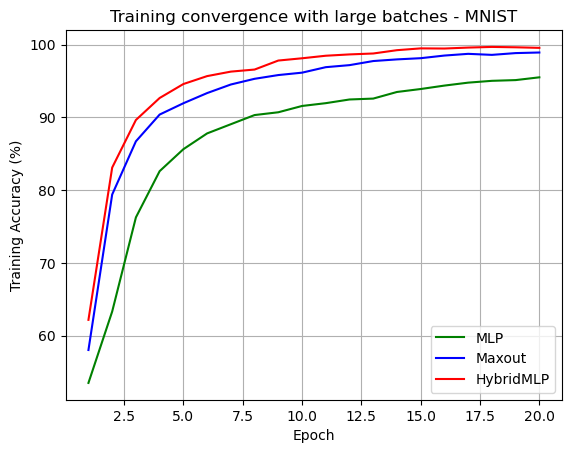

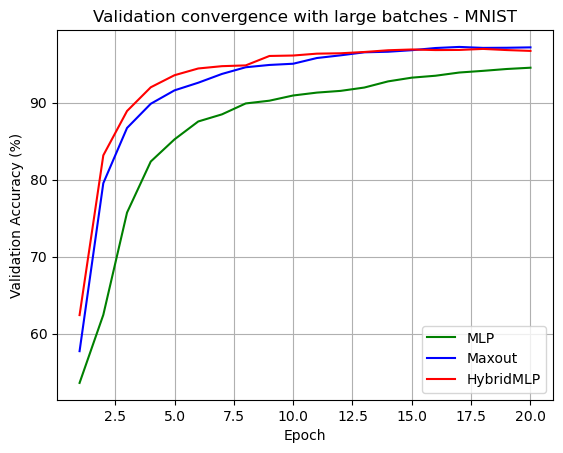

In [68]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_mnist_2.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_mnist_2.pdf", format='pdf', dpi=1000)
plt.show()

In [69]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [70]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 1.7362, Train Accuracy: 53.51%, Validation Accuracy: 53.11%
Epoch [2/20], Loss: 0.9202, Train Accuracy: 64.39%, Validation Accuracy: 64.15%
Epoch [3/20], Loss: 0.7795, Train Accuracy: 67.81%, Validation Accuracy: 67.65%
Epoch [4/20], Loss: 0.7123, Train Accuracy: 72.38%, Validation Accuracy: 71.43%
Epoch [5/20], Loss: 0.6448, Train Accuracy: 75.27%, Validation Accuracy: 74.24%
Epoch [6/20], Loss: 0.5841, Train Accuracy: 78.08%, Validation Accuracy: 77.28%
Epoch [7/20], Loss: 0.5591, Train Accuracy: 79.80%, Validation Accuracy: 78.88%
Epoch [8/20], Loss: 0.4889, Train Accuracy: 81.59%, Validation Accuracy: 80.97%
Epoch [9/20], Loss: 0.4644, Train Accuracy: 82.46%, Validation Accuracy: 82.02%
Epoch [10/20], Loss: 0.4598, Train Accuracy: 83.72%, Validation Accuracy: 82.81%
Epoch [11/20], Loss: 0.4332, Train Accuracy: 84.37%, Validation Accuracy: 83.26%
Epoch [12/20], Loss: 0.3996, Train Accuracy: 84.63%, Validation Accuracy: 83.40%
Ep

In [71]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826


Epoch [1/20], Loss: 1.0125, Train Accuracy: 53.78%, Validation Accuracy: 53.06%
Epoch [2/20], Loss: 0.6951, Train Accuracy: 72.89%, Validation Accuracy: 71.74%
Epoch [3/20], Loss: 0.6232, Train Accuracy: 77.03%, Validation Accuracy: 76.33%
Epoch [4/20], Loss: 0.5164, Train Accuracy: 80.28%, Validation Accuracy: 79.65%
Epoch [5/20], Loss: 0.4883, Train Accuracy: 82.14%, Validation Accuracy: 81.59%
Epoch [6/20], Loss: 0.4409, Train Accuracy: 83.45%, Validation Accuracy: 82.98%
Epoch [7/20], Loss: 0.4327, Train Accuracy: 84.86%, Validation Accuracy: 84.17%
Epoch [8/20], Loss: 0.4110, Train Accuracy: 84.69%, Validation Accuracy: 84.15%
Epoch [9/20], Loss: 0.3927, Train Accuracy: 85.56%, Validation Accuracy: 84.66%
Epoch [10/20], Loss: 0.3637, Train Accuracy: 86.99%, Validation Accuracy: 86.02%
Epoch [11/20], Loss: 0.3626, Train Accuracy: 86.78%, Validation Accuracy: 85.78%
Epoch [12/20], Loss: 0.3257, Train Accuracy: 87.58%, Validation Accuracy: 86.26%
Epoch [13/20], Loss: 0.3184, Train Ac

In [72]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938
Epoch [1/20], Loss: 1.0972, Train Accuracy: 73.24%, Validation Accuracy: 72.40%
Epoch [2/20], Loss: 0.6189, Train Accuracy: 79.13%, Validation Accuracy: 78.84%
Epoch [3/20], Loss: 0.5186, Train Accuracy: 83.28%, Validation Accuracy: 82.82%
Epoch [4/20], Loss: 0.4173, Train Accuracy: 84.50%, Validation Accuracy: 83.60%
Epoch [5/20], Loss: 0.3870, Train Accuracy: 86.70%, Validation Accuracy: 85.58%
Epoch [6/20], Loss: 0.3518, Train Accuracy: 87.56%, Validation Accuracy: 86.03%
Epoch [7/20], Loss: 0.3119, Train Accuracy: 88.53%, Validation Accuracy: 86.43%
Epoch [8/20], Loss: 0.3011, Train Accuracy: 89.34%, Validation Accuracy: 87.16%
Epoch [9/20], Loss: 0.3205, Train Accuracy: 90.02%, Validation Accuracy: 87.63%
Epoch [10/20], Loss: 0.2895, Train Accuracy: 90.09%, Validation Accuracy: 87.04%
Epoch [11/20], Loss: 0.2943, Train Accuracy: 90.66%, Validation Accuracy: 87.42%
Epoch [12/20], Loss: 0.2301, Train Accuracy: 91.53%, Validation Accuracy: 87.33%
Ep

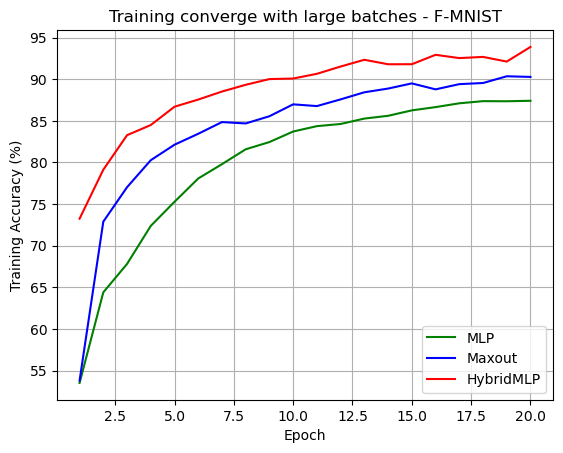

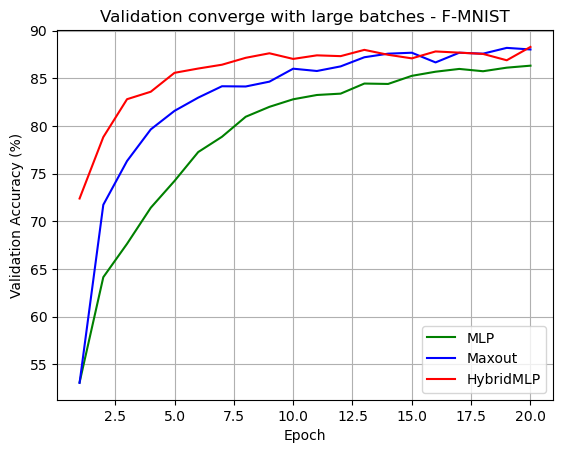

In [73]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_fashion_mnist_2.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_fashion_mnist_2.pdf", format='pdf', dpi=1000)
plt.show()

In [74]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [75]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938


Epoch [1/50], Loss: 2.9268, Train Accuracy: 9.32%, Validation Accuracy: 9.38%
Epoch [2/50], Loss: 2.2180, Train Accuracy: 16.46%, Validation Accuracy: 16.88%
Epoch [3/50], Loss: 2.0986, Train Accuracy: 20.71%, Validation Accuracy: 20.96%
Epoch [4/50], Loss: 1.7881, Train Accuracy: 25.88%, Validation Accuracy: 26.49%
Epoch [5/50], Loss: 1.9045, Train Accuracy: 23.79%, Validation Accuracy: 23.86%
Epoch [6/50], Loss: 1.9782, Train Accuracy: 26.75%, Validation Accuracy: 26.61%
Epoch [7/50], Loss: 1.9134, Train Accuracy: 30.03%, Validation Accuracy: 30.21%
Epoch [8/50], Loss: 1.6988, Train Accuracy: 28.47%, Validation Accuracy: 27.68%
Epoch [9/50], Loss: 1.7341, Train Accuracy: 27.53%, Validation Accuracy: 28.13%
Epoch [10/50], Loss: 1.7244, Train Accuracy: 33.25%, Validation Accuracy: 33.81%
Epoch [11/50], Loss: 108.1385, Train Accuracy: 9.73%, Validation Accuracy: 9.98%
Epoch [12/50], Loss: 1.8342, Train Accuracy: 25.24%, Validation Accuracy: 25.40%
Epoch [13/50], Loss: 1.9038, Train Accu

In [76]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 33.44%


In [77]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [78]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938


Epoch [1/50], Loss: 0.2039, Train Accuracy: 93.99%, Validation Accuracy: 93.38%
Epoch [2/50], Loss: 0.1887, Train Accuracy: 95.34%, Validation Accuracy: 94.44%
Epoch [3/50], Loss: 0.1185, Train Accuracy: 96.06%, Validation Accuracy: 95.03%
Epoch [4/50], Loss: 0.1096, Train Accuracy: 97.09%, Validation Accuracy: 95.72%
Epoch [5/50], Loss: 0.0902, Train Accuracy: 97.73%, Validation Accuracy: 96.54%
Epoch [6/50], Loss: 0.1322, Train Accuracy: 96.30%, Validation Accuracy: 95.37%
Epoch [7/50], Loss: 0.0867, Train Accuracy: 97.14%, Validation Accuracy: 95.84%
Epoch [8/50], Loss: 0.1246, Train Accuracy: 97.45%, Validation Accuracy: 95.90%
Epoch [9/50], Loss: 0.1030, Train Accuracy: 97.63%, Validation Accuracy: 96.13%
Epoch [10/50], Loss: 0.0937, Train Accuracy: 96.93%, Validation Accuracy: 95.47%
Epoch [11/50], Loss: 0.1242, Train Accuracy: 97.94%, Validation Accuracy: 96.33%
Epoch [12/50], Loss: 0.0743, Train Accuracy: 97.58%, Validation Accuracy: 95.96%
Epoch [13/50], Loss: 0.0586, Train Ac

In [79]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.97%


In [80]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [81]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 1.6945, Train Accuracy: 64.45%, Validation Accuracy: 63.57%
Epoch [2/50], Loss: 0.7284, Train Accuracy: 83.59%, Validation Accuracy: 82.92%
Epoch [3/50], Loss: 0.3730, Train Accuracy: 90.39%, Validation Accuracy: 89.75%
Epoch [4/50], Loss: 0.2742, Train Accuracy: 92.94%, Validation Accuracy: 92.61%
Epoch [5/50], Loss: 0.2062, Train Accuracy: 94.40%, Validation Accuracy: 93.82%
Epoch [6/50], Loss: 0.1645, Train Accuracy: 95.90%, Validation Accuracy: 94.83%
Epoch [7/50], Loss: 0.1436, Train Accuracy: 96.89%, Validation Accuracy: 95.46%
Epoch [8/50], Loss: 0.1000, Train Accuracy: 97.56%, Validation Accuracy: 96.06%
Epoch [9/50], Loss: 0.0835, Train Accuracy: 97.86%, Validation Accuracy: 96.20%
Epoch [10/50], Loss: 0.0757, Train Accuracy: 97.93%, Validation Accuracy: 96.09%
Epoch [11/50], Loss: 0.0710, Train Accuracy: 98.61%, Validation Accuracy: 96.82%
Epoch [12/50], Loss: 0.0531, Train Accuracy: 98.96%, Validation Accuracy: 96.79%
Ep

In [82]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.21%


In [83]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [84]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 27.8912, Train Accuracy: 13.97%, Validation Accuracy: 13.95%
Epoch [2/50], Loss: 2.1903, Train Accuracy: 11.16%, Validation Accuracy: 10.80%
Epoch [3/50], Loss: 2.1056, Train Accuracy: 22.09%, Validation Accuracy: 21.83%
Epoch [4/50], Loss: 2.2801, Train Accuracy: 13.86%, Validation Accuracy: 13.59%
Epoch [5/50], Loss: 1.9955, Train Accuracy: 22.23%, Validation Accuracy: 21.99%
Epoch [6/50], Loss: 2.2862, Train Accuracy: 27.40%, Validation Accuracy: 27.48%
Epoch [7/50], Loss: 2.1986, Train Accuracy: 17.36%, Validation Accuracy: 17.60%
Epoch [8/50], Loss: 1.8205, Train Accuracy: 22.54%, Validation Accuracy: 22.89%
Epoch [9/50], Loss: 1.7050, Train Accuracy: 28.79%, Validation Accuracy: 29.32%
Epoch [10/50], Loss: 1.9684, Train Accuracy: 28.27%, Validation Accuracy: 29.23%
Epoch [11/50], Loss: 1.6067, Train Accuracy: 30.95%, Validation Accuracy: 31.23%
Epoch [12/50], Loss: 1.6275, Train Accuracy: 27.69%, Validation Accuracy: 28.35%
E

In [85]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 37.58%


In [86]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [87]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938


Epoch [1/50], Loss: 0.4570, Train Accuracy: 84.02%, Validation Accuracy: 83.81%
Epoch [2/50], Loss: 0.3919, Train Accuracy: 86.09%, Validation Accuracy: 85.33%
Epoch [3/50], Loss: 0.3955, Train Accuracy: 87.69%, Validation Accuracy: 86.32%
Epoch [4/50], Loss: 0.3651, Train Accuracy: 86.85%, Validation Accuracy: 85.33%
Epoch [5/50], Loss: 0.2995, Train Accuracy: 88.71%, Validation Accuracy: 87.03%
Epoch [6/50], Loss: 0.2864, Train Accuracy: 89.47%, Validation Accuracy: 87.30%
Epoch [7/50], Loss: 0.3340, Train Accuracy: 89.11%, Validation Accuracy: 87.02%
Epoch [8/50], Loss: 0.2795, Train Accuracy: 90.17%, Validation Accuracy: 87.65%
Epoch [9/50], Loss: 0.2452, Train Accuracy: 90.24%, Validation Accuracy: 87.43%
Epoch [10/50], Loss: 0.3380, Train Accuracy: 89.58%, Validation Accuracy: 87.14%
Epoch [11/50], Loss: 0.2330, Train Accuracy: 91.10%, Validation Accuracy: 88.33%
Epoch [12/50], Loss: 0.2935, Train Accuracy: 91.05%, Validation Accuracy: 88.25%
Epoch [13/50], Loss: 0.2175, Train Ac

In [88]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.01%


In [89]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [90]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 1.1645, Train Accuracy: 70.82%, Validation Accuracy: 70.97%
Epoch [2/50], Loss: 0.6191, Train Accuracy: 78.88%, Validation Accuracy: 78.74%
Epoch [3/50], Loss: 0.4882, Train Accuracy: 83.19%, Validation Accuracy: 82.75%
Epoch [4/50], Loss: 0.4118, Train Accuracy: 85.04%, Validation Accuracy: 84.76%
Epoch [5/50], Loss: 0.3934, Train Accuracy: 87.02%, Validation Accuracy: 86.14%
Epoch [6/50], Loss: 0.3547, Train Accuracy: 87.72%, Validation Accuracy: 86.42%
Epoch [7/50], Loss: 0.3385, Train Accuracy: 88.58%, Validation Accuracy: 86.93%
Epoch [8/50], Loss: 0.3040, Train Accuracy: 89.26%, Validation Accuracy: 87.39%
Epoch [9/50], Loss: 0.3078, Train Accuracy: 89.98%, Validation Accuracy: 87.68%
Epoch [10/50], Loss: 0.2693, Train Accuracy: 90.26%, Validation Accuracy: 87.61%
Epoch [11/50], Loss: 0.2698, Train Accuracy: 90.99%, Validation Accuracy: 88.08%
Epoch [12/50], Loss: 0.2791, Train Accuracy: 90.60%, Validation Accuracy: 87.61%
Ep

In [91]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.49%


### Compression experiments

In [92]:
def prune_weightsMLP(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            weight = layer.weight.data
            num_to_prune = int(pruning_ratio * weight.numel())

            # Get absolute values and sort
            flat_weights = weight.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            weight[weight.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer(model.fc1)
    for layer in model.fcs:
        prune_layer(layer)
    prune_layer(model.fc2)

    return model  # Return the pruned model

def prune_weightsMPM(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        morph_layer, linact = layer[0], layer[1]
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            w = morph_layer.w.data
            num_to_prune = int(pruning_ratio * w.numel())

            # Get absolute values and so
            flat_weights = w.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            w[w.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer([model.morph_layer1, model.linact1])
    for layer in model.morph_layers:
        prune_layer(layer)
    prune_layer([model.morph_layer2, None])

    return model  # Return the pruned model

In [93]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [94]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.3215, Train Accuracy: 93.82%, Validation Accuracy: 93.30%
Epoch [2/50], Loss: 0.2771, Train Accuracy: 94.75%, Validation Accuracy: 93.88%
Epoch [3/50], Loss: 0.0955, Train Accuracy: 96.87%, Validation Accuracy: 95.96%
Epoch [4/50], Loss: 0.2179, Train Accuracy: 97.31%, Validation Accuracy: 96.30%
Epoch [5/50], Loss: 0.0282, Train Accuracy: 97.68%, Validation Accuracy: 96.69%
Epoch [6/50], Loss: 0.0513, Train Accuracy: 97.88%, Validation Accuracy: 96.58%
Epoch [7/50], Loss: 0.0469, Train Accuracy: 97.75%, Validation Accuracy: 96.36%
Epoch [8/50], Loss: 0.0281, Train Accuracy: 97.70%, Validation Accuracy: 96.23%
Epoch [9/50], Loss: 0.1610, Train Accuracy: 98.24%, Validation Accuracy: 96.83%
Epoch [10/50], Loss: 0.0386, Train Accuracy: 98.58%, Validation Accuracy: 97.29%
Epoch [11/50], Loss: 0.0438, Train Accuracy: 98.77%, Validation Accuracy: 97.18%
Epoch [12/50], Loss: 0.0030, Train Accuracy: 98.72%, Validation Accuracy: 97.07%
Ep

In [95]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.91%


In [96]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 79.33%
Pruning ratio: 0.875
Accuracy on the test set: 64.53%
Pruning ratio: 0.9
Accuracy on the test set: 43.11%
Pruning ratio: 0.925
Accuracy on the test set: 19.61%
Pruning ratio: 0.95
Accuracy on the test set: 14.05%
Pruning ratio: 0.975
Accuracy on the test set: 9.67%


In [97]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.7937, Train Accuracy: 83.70%, Validation Accuracy: 83.47%
Epoch [2/50], Loss: 0.2577, Train Accuracy: 90.55%, Validation Accuracy: 89.77%
Epoch [3/50], Loss: 0.2523, Train Accuracy: 92.96%, Validation Accuracy: 91.62%
Epoch [4/50], Loss: 0.2020, Train Accuracy: 94.03%, Validation Accuracy: 92.45%
Epoch [5/50], Loss: 0.4344, Train Accuracy: 94.79%, Validation Accuracy: 92.67%
Epoch [6/50], Loss: 0.2054, Train Accuracy: 95.36%, Validation Accuracy: 93.33%
Epoch [7/50], Loss: 0.1444, Train Accuracy: 95.80%, Validation Accuracy: 93.56%
Epoch [8/50], Loss: 0.1241, Train Accuracy: 96.28%, Validation Accuracy: 93.69%
Epoch [9/50], Loss: 0.1283, Train Accuracy: 96.73%, Validation Accuracy: 94.03%
Epoch [10/50], Loss: 0.1266, Train Accuracy: 96.99%, Validation Accuracy: 94.12%
Epoch [11/50], Loss: 0.0696, Train Accuracy: 97.18%, Validation Accuracy: 94.29%
Epoch [12/50], Loss: 0.1564, Train Accuracy: 97.45%, Validation Accuracy: 94.34%
Ep

In [98]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.66%


In [99]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 93.70%
Pruning ratio: 0.875
Accuracy on the test set: 92.69%
Pruning ratio: 0.9
Accuracy on the test set: 91.43%
Pruning ratio: 0.925
Accuracy on the test set: 89.68%
Pruning ratio: 0.95
Accuracy on the test set: 58.98%
Pruning ratio: 0.975
Accuracy on the test set: 63.66%


In [100]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [101]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698


Epoch [1/50], Loss: 0.5347, Train Accuracy: 84.58%, Validation Accuracy: 84.06%
Epoch [2/50], Loss: 0.3071, Train Accuracy: 86.20%, Validation Accuracy: 85.31%
Epoch [3/50], Loss: 0.1598, Train Accuracy: 84.44%, Validation Accuracy: 83.48%
Epoch [4/50], Loss: 0.2693, Train Accuracy: 88.51%, Validation Accuracy: 87.26%
Epoch [5/50], Loss: 0.2577, Train Accuracy: 88.81%, Validation Accuracy: 86.95%
Epoch [6/50], Loss: 0.4474, Train Accuracy: 89.94%, Validation Accuracy: 87.66%
Epoch [7/50], Loss: 0.1248, Train Accuracy: 90.02%, Validation Accuracy: 87.97%
Epoch [8/50], Loss: 0.1129, Train Accuracy: 90.81%, Validation Accuracy: 88.28%
Epoch [9/50], Loss: 0.1783, Train Accuracy: 90.91%, Validation Accuracy: 88.12%
Epoch [10/50], Loss: 0.1668, Train Accuracy: 90.68%, Validation Accuracy: 87.78%
Epoch [11/50], Loss: 0.2626, Train Accuracy: 91.70%, Validation Accuracy: 88.65%
Epoch [12/50], Loss: 0.1254, Train Accuracy: 91.00%, Validation Accuracy: 87.85%
Epoch [13/50], Loss: 0.2349, Train Ac

In [102]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.78%


In [103]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 52.47%
Pruning ratio: 0.875
Accuracy on the test set: 32.46%
Pruning ratio: 0.9
Accuracy on the test set: 18.11%
Pruning ratio: 0.925
Accuracy on the test set: 15.69%
Pruning ratio: 0.95
Accuracy on the test set: 12.38%
Pruning ratio: 0.975
Accuracy on the test set: 10.30%


In [104]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268


Epoch [1/50], Loss: 0.8205, Train Accuracy: 77.04%, Validation Accuracy: 75.81%
Epoch [2/50], Loss: 0.6991, Train Accuracy: 83.04%, Validation Accuracy: 80.97%
Epoch [3/50], Loss: 0.5040, Train Accuracy: 85.51%, Validation Accuracy: 82.22%
Epoch [4/50], Loss: 0.5452, Train Accuracy: 87.09%, Validation Accuracy: 82.73%
Epoch [5/50], Loss: 0.3056, Train Accuracy: 88.50%, Validation Accuracy: 83.04%
Epoch [6/50], Loss: 0.3663, Train Accuracy: 89.06%, Validation Accuracy: 83.07%
Epoch [7/50], Loss: 0.2463, Train Accuracy: 90.36%, Validation Accuracy: 83.38%
Epoch [8/50], Loss: 0.4042, Train Accuracy: 91.04%, Validation Accuracy: 83.50%
Epoch [9/50], Loss: 0.3340, Train Accuracy: 91.65%, Validation Accuracy: 83.38%
Epoch [10/50], Loss: 0.2488, Train Accuracy: 91.91%, Validation Accuracy: 83.14%
Epoch [11/50], Loss: 0.1528, Train Accuracy: 92.64%, Validation Accuracy: 83.39%
Epoch [12/50], Loss: 0.1818, Train Accuracy: 93.28%, Validation Accuracy: 83.47%
Epoch [13/50], Loss: 0.2625, Train Ac

In [105]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 82.53%


In [106]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85


Accuracy on the test set: 79.30%
Pruning ratio: 0.875
Accuracy on the test set: 79.16%
Pruning ratio: 0.9
Accuracy on the test set: 78.28%
Pruning ratio: 0.925
Accuracy on the test set: 75.17%
Pruning ratio: 0.95
Accuracy on the test set: 75.16%
Pruning ratio: 0.975
Accuracy on the test set: 62.84%
